# 🔋 Stage 4 — Energy-Aware Adaptive Inference

**Project:** Energy-Aware Visual Anomaly Detection on MCUs — Stage 4 / 4

Based on remaining energy, the device could hold a **ladder** of compressed models and switch between them at runtime.

**The goal:**
 - run accurate (expensive) model when energy is plentiful
 - as the battery depletes, drop to cheaper models, trading accuracy for survival.

## What this notebook does

1. Load **measured** energy/accuracy/size ladder from Stage 3 (real on-device latency → energy, real on-device AUROC, real model size).
2. Simulate a **depleting battery** powering continuous inference.
3. Implements two adaptive selection policies:
    - **threshold** (energy bands)
    - **utility** (maximize expected accuracy under a survival constraint).
4. Compares adaptive vs fixed-model baselines on:
    - total inferences served
    - average accuracy delivered
    - graceful degradation

Since edge devices often run on batteries or harvested energy, a computational expensive model dies early.
Nevertheless a cheap but inaccurate model is pointless even though energy is plentiful.

--> An adaptive selection could get the best of both.

---

## 1. The measured ladder
From Stage 3:
 - real on-device latency → energy (datasheet power)
 - real on-device AUROC
 - on-device SRAM usage
 - on-device model-size

Matches `ondevice_results.csv`.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Datasheet power model (nRF52840 active @ 64 MHz)
SUPPLY_V   = 3.3
CURRENT_MA = 6.3
POWER_MW   = SUPPLY_V * CURRENT_MA      # 20.79 mW

def energy_mJ(latency_ms):
    return POWER_MW * latency_ms / 1000.0


# === MEASURED on-device numbers ===
# NOTE: memory values are now in KB (bytes / 1000)
LADDER = {
    'bottle': {
        'prune30': {
            'latency_ms': 3354.8,
            'auroc': 0.9603 * 100,
            'SRAM_KB': 117764 / 1000,
            'model_size_KB': 221984 / 1000,
        },
        'prune50': {
            'latency_ms': 2059.3,
            'auroc': 0.9460 * 100,
            'SRAM_KB': 86212 / 1000,
            'model_size_KB': 136208 / 1000,
        },
        'distill': {
            'latency_ms': 1992.0,
            'auroc': 0.9373 * 100,
            'SRAM_KB': 86084 / 1000,
            'model_size_KB': 110160 / 1000,
        },
    },

    'hazelnut': {
        'prune30': {
            'latency_ms': 3356.0,
            'auroc': 0.8900 * 100,
            'SRAM_KB': 117764 / 1000,
            'model_size_KB': 221984 / 1000,
        },
        'prune50': {
            'latency_ms': 2059.9,
            'auroc': 0.8839 * 100,
            'SRAM_KB': 86212 / 1000,
            'model_size_KB': 136298 / 1000,
        },
        'distill': {
            'latency_ms': 1992.0,
            'auroc': 0.8232 * 100,
            'SRAM_KB': 86084 / 1000,
            'model_size_KB': 110160 / 1000,
        },
    },
}

# derive energy
for cat in LADDER:
    for name, m in LADDER[cat].items():
        m['energy_mJ'] = energy_mJ(m['latency_ms'])


# show ladder sorted by energy (descending)
for cat in LADDER:
    print(f'\n{cat}:')
    for name, m in sorted(LADDER[cat].items(),
                          key=lambda kv: -kv[1]['energy_mJ']):

        print(
            f"  {name:8s}  "
            f"{m['energy_mJ']:5.1f} mJ   "
            f"AUROC {m['auroc']:.3f}   "
            f"SRAM {m['SRAM_KB']:7.1f} KB   "
            f"SIZE {m['model_size_KB']:7.1f} KB   "
            f"({m['latency_ms']} ms)"
        )


bottle:
  prune30    69.7 mJ   AUROC 96.030   SRAM   117.8 KB   SIZE   222.0 KB   (3354.8 ms)
  prune50    42.8 mJ   AUROC 94.600   SRAM    86.2 KB   SIZE   136.2 KB   (2059.3 ms)
  distill    41.4 mJ   AUROC 93.730   SRAM    86.1 KB   SIZE   110.2 KB   (1992.0 ms)

hazelnut:
  prune30    69.8 mJ   AUROC 89.000   SRAM   117.8 KB   SIZE   222.0 KB   (3356.0 ms)
  prune50    42.8 mJ   AUROC 88.390   SRAM    86.2 KB   SIZE   136.3 KB   (2059.9 ms)
  distill    41.4 mJ   AUROC 82.320   SRAM    86.1 KB   SIZE   110.2 KB   (1992.0 ms)


## 2. Visualize the energy/accuracy trade-off

Pareto curve - Accuracy vs. energy

The adaptive policy moves along this curve as energy changes.

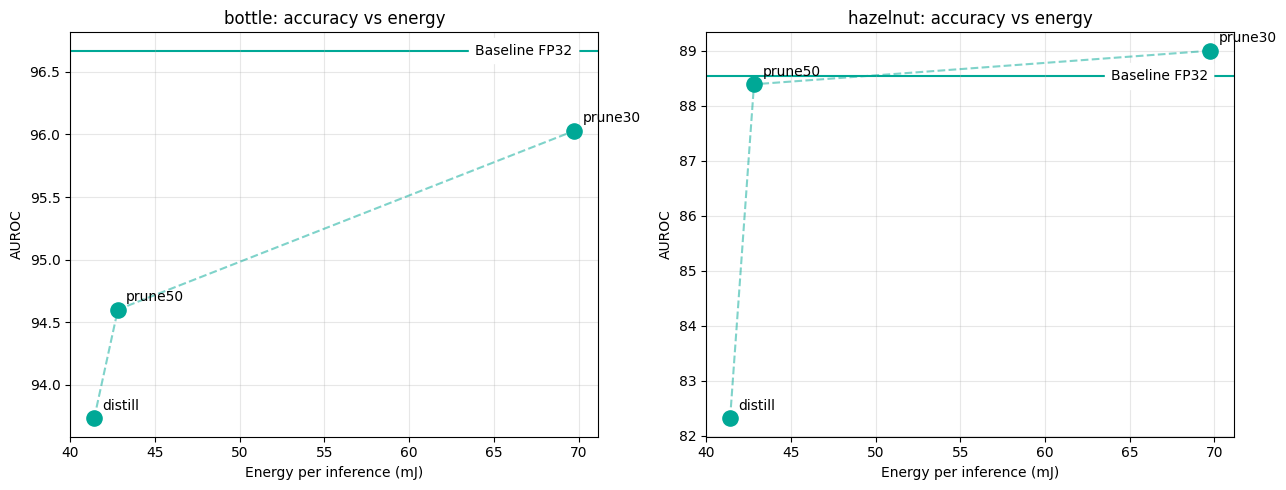

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ref_aurocs = {
    "bottle": 96.67,
    "hazelnut": 88.54
}

for ax, cat in zip(axes, LADDER):
    names = list(LADDER[cat].keys())
    e = [LADDER[cat][n]['energy_mJ'] for n in names]
    a = [LADDER[cat][n]['auroc'] for n in names]

    ax.scatter(e, a, s=120, color="#00a896", zorder=3)

    for n, x, y in zip(names, e, a):
        ax.annotate(n, (x, y), xytext=(6, 6), textcoords='offset points', fontsize=10)

    # connect in energy order
    order = np.argsort(e)
    ax.plot(np.array(e)[order], np.array(a)[order], '--', color="#00a896", alpha=.5, zorder=2)

    # Add AUROC reference line
    ax.axhline(
    y=ref_aurocs[cat],
    color="#00a896",
    linestyle='-',
    linewidth=1.5,
    zorder=1,
    )
    # Label directly on the line, inside the axes
    x_min, x_max = ax.get_xlim()
    ax.text(
        x_max - 0.05 * (x_max - x_min),  # slightly left of right border
        ref_aurocs[cat],
        "Baseline FP32",
        fontsize=10,
        va="center",
        ha="right",
        backgroundcolor="white",
        zorder=5
    )

    ax.set_xlabel('Energy per inference (mJ)')
    ax.set_ylabel('AUROC')
    ax.set_title(f'{cat}: accuracy vs energy')
    ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig("AccuracyVsEnergy.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Battery model

A simple coulomb-counting battery simulation:
 - start with a fixed charge (mJ)
 - each inference subtracts
    - the according model's energy +
    - a small idle/sleep cost between inferences
 - the device 'dies' when charge hits zero.

**The baseline:** Always running the same model

*"How many inferences are possible when running a single model until battery dies?"*

In [33]:
# Battery: a small coin/Li cell. Capacity in mJ.
# Example: CR2032 ~225 mAh @ 3V = 0.225*3*3600 J = 2430 J = 2.43e6 mJ (huge).
# For a watchable simulation we scale to a tiny budget so depletion is visible.
BATTERY_mJ = 5000.0          # tweak so the sim runs ~100-300 inferences
IDLE_mJ    = 2.0             # per-cycle idle/sleep cost between inferences

def battery_runtime_inferences(cap_mJ, energy_per_inf):
    """How many inferences a FIXED model achieves on a full battery."""
    return int(cap_mJ // (energy_per_inf + IDLE_mJ))

for cat in LADDER:
  print(f'\n{cat}:')
  print(f'Fixed-model runtime on {BATTERY_mJ:.0f} mJ battery')
  for n, m in LADDER[cat].items():
    k = battery_runtime_inferences(BATTERY_mJ, m['energy_mJ'])
    print(f"  always-{n:8s}: {k:4d} inferences, AUROC {m['auroc']:.3f} throughout")


bottle:
Fixed-model runtime on 5000 mJ battery
  always-prune30 :   69 inferences, AUROC 96.030 throughout
  always-prune50 :  111 inferences, AUROC 94.600 throughout
  always-distill :  115 inferences, AUROC 93.730 throughout

hazelnut:
Fixed-model runtime on 5000 mJ battery
  always-prune30 :   69 inferences, AUROC 89.000 throughout
  always-prune50 :  111 inferences, AUROC 88.390 throughout
  always-distill :  115 inferences, AUROC 82.320 throughout


## 4. The adaptive policies

**Threshold policy**:
 - partition the battery into bands
 - run the accurate model when full, drop to cheaper models as charge falls

| Battery charge | Deployment | Chosen Model |
|---|---|---|
| >66% | accurate | Prune30 |
| 33-66% | mid | Prune 50 |
| >33% | cheap | Distill |

```
if battery high:
    expensive model

elif medium:
    medium model

else:
    cheap model
```

**Utility policy**:
 - at each step, estimate remaining inferences if we used the cheapest model
 - pick the most accurate model affordable while guaranteeing a target number of future inferences --> 50

 ```
 if remaining energy >= target future inferences * cheapest_e:
    stay with accurate model
 else:
    switch to cheap model
 ```

 --> It becomes an optimization problem:

maximize accuracy - subject to - survival constraint.

In [34]:
def policy_threshold(charge_frac, ladder_sorted):
    """charge_frac in [0,1]. Bands: >66% accurate, 33-66% mid, <33% cheap.
    ladder_sorted: list of (name, model) from MOST to LEAST expensive."""
    if charge_frac > 0.66:   return ladder_sorted[0]      # most accurate
    elif charge_frac > 0.33: return ladder_sorted[len(ladder_sorted)//2]
    else:                    return ladder_sorted[-1]     # cheapest

def policy_utility(charge_mJ, ladder_sorted, target_survival=50):
    """Pick the most accurate model such that, after running it, we could still
    survive `target_survival` more inferences on the cheapest model."""
    cheapest_e = ladder_sorted[-1][1]['energy_mJ'] + IDLE_mJ
    for name, m in ladder_sorted:           # most -> least expensive
        cost = m['energy_mJ'] + IDLE_mJ
        remaining_after = charge_mJ - cost
        if remaining_after >= target_survival * cheapest_e:
            return (name, m)
    return ladder_sorted[-1]                 # can't afford survival margin -> cheapest

## 5. Simulate full battery lifetime under each strategy

In [35]:
def simulate(cat, strategy, cap_mJ=BATTERY_mJ, **kw):
    """Run inferences until the battery dies. Returns per-step trace."""
    ladder_sorted = sorted(LADDER[cat].items(), key=lambda kv: -kv[1]['energy_mJ'])  # expensive first
    charge = cap_mJ
    trace = {'charge': [], 'model': [], 'auroc': []}
    while charge > 0:
        if strategy == 'threshold':
            name, m = policy_threshold(charge/cap_mJ, ladder_sorted)
        elif strategy == 'utility':
            name, m = policy_utility(charge, ladder_sorted, kw.get('target_survival', 50))
        else:  # fixed model, strategy = model name
            name = strategy; m = LADDER[cat][name]
        cost = m['energy_mJ'] + IDLE_mJ
        if charge < cost: break
        charge -= cost
        trace['charge'].append(charge); trace['model'].append(name); trace['auroc'].append(m['auroc'])
    return trace

In [36]:
strategies = {
    'always-prune30': 'prune30',
    'always-prune50': 'prune50',
    'always-distill': 'distill',
    'threshold':      'threshold',
    'utility':        'utility',
}

all_results = {}

for cat in LADDER:
  results = {}
  print(f'\n --- {cat} ---')
  print()
  for label, strat in strategies.items():
      tr = simulate(cat, strat)
      n = len(tr['auroc'])
      mean_auroc = np.mean(tr['auroc']) if n else 0
      results[label] = {'trace': tr, 'n_inferences': n, 'mean_auroc': mean_auroc}
      print(f'{label:18s}: {n:4d} inferences served, mean AUROC delivered = {mean_auroc:.4f}')
  all_results[cat] = results



 --- bottle ---

always-prune30    :   69 inferences served, mean AUROC delivered = 96.0300
always-prune50    :  111 inferences served, mean AUROC delivered = 94.6000
always-distill    :  115 inferences served, mean AUROC delivered = 93.7300
threshold         :   98 inferences served, mean AUROC delivered = 94.6217
utility           :   89 inferences served, mean AUROC delivered = 94.7379

 --- hazelnut ---

always-prune30    :   69 inferences served, mean AUROC delivered = 89.0000
always-prune50    :  111 inferences served, mean AUROC delivered = 88.3900
always-distill    :  115 inferences served, mean AUROC delivered = 82.3200
threshold         :   98 inferences served, mean AUROC delivered = 86.2477
utility           :   89 inferences served, mean AUROC delivered = 85.2472


## 6. Headline plot — which model runs as the battery drains

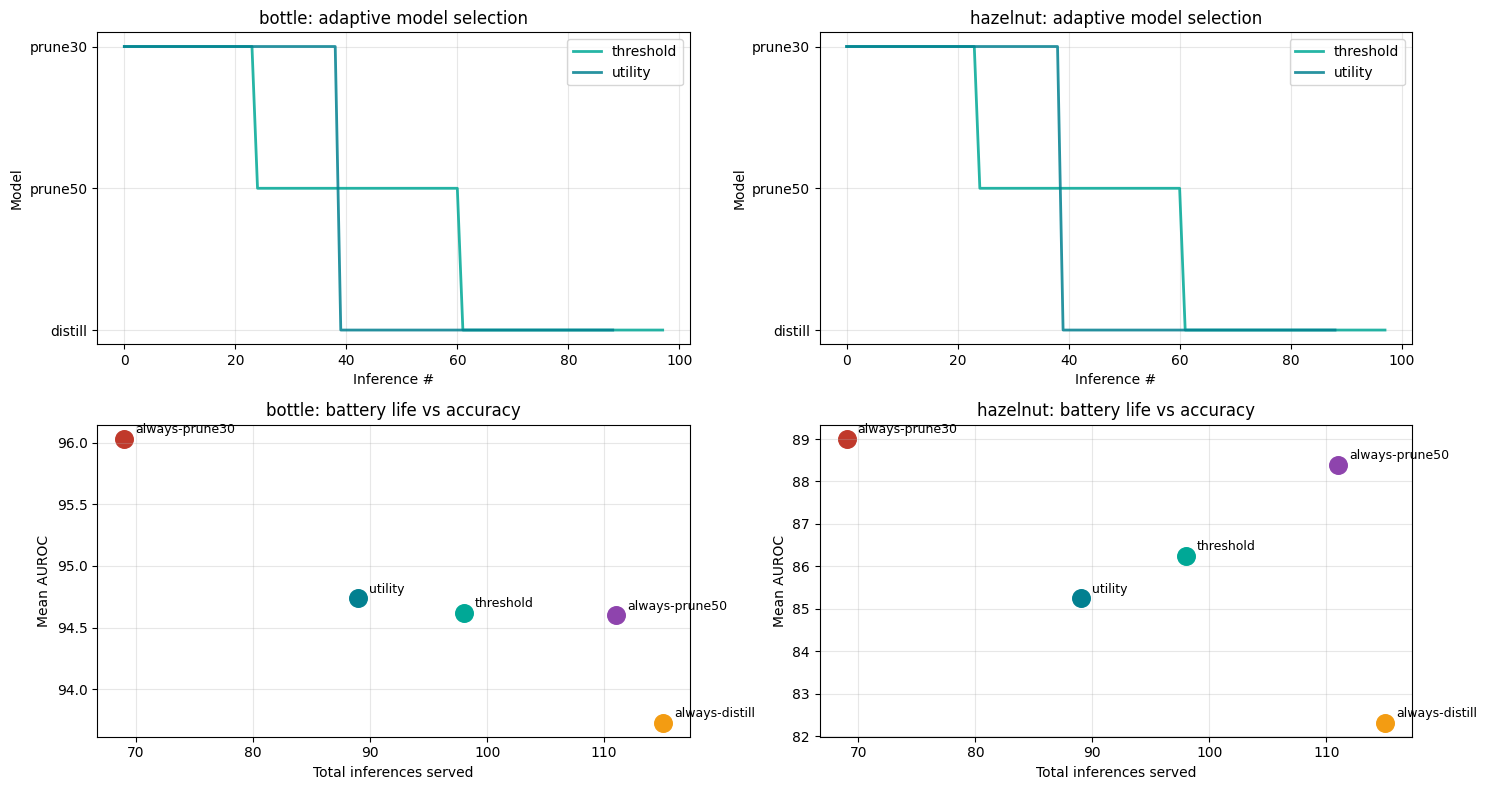

In [37]:
model_to_y = {'prune30': 3, 'prune50': 2, 'distill': 1}

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# --------------------------
# FIXED COLORS
# --------------------------
label_colors = {
    "utility": "#028090",     # AUROC (on-device style color)
    "threshold": "#00a896",   # Pareto-style green
}

# High-contrast fallback palette for other labels
fallback_colors = ["#c0392b", "#8e44ad", "#f39c12", "#2c3e50"]

for col, (cat, results) in enumerate(all_results.items()):

    # ==========================
    # Top row: model selection
    # ==========================
    ax = axes[0, col]

    for label in ["threshold", "utility"]:
        tr = results[label]["trace"]
        ys = [model_to_y[m] for m in tr["model"]]

        ax.plot(
            range(len(ys)),
            ys,
            lw=2,
            alpha=0.85,
            color=label_colors[label],
            label=label,
        )

    ax.set_title(f"{cat}: adaptive model selection")
    ax.set_xlabel("Inference #")
    ax.set_ylabel("Model")
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["distill", "prune50", "prune30"])
    ax.grid(alpha=0.3)
    ax.legend()

    # ==========================
    # Bottom row: battery vs accuracy
    # ==========================
    ax = axes[1, col]

    labels = list(results.keys())

    for i, l in enumerate(labels):
        n = results[l]["n_inferences"]
        a = results[l]["mean_auroc"]

        # choose color
        c = label_colors.get(l, fallback_colors[i % len(fallback_colors)])

        ax.scatter(n, a, s=160, color=c)

        ax.annotate(
            l,
            (n, a),
            xytext=(8, 4),
            textcoords="offset points",
            fontsize=9,
        )

    ax.set_title(f"{cat}: battery life vs accuracy")
    ax.set_xlabel("Total inferences served")
    ax.set_ylabel("Mean AUROC")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ModelSelection_InferencesVsAccuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Comparisons

**Mean AUROC:**
 - Average detection quality over lifetime

**Accuracy × runtime:**
 - combine quality and lifetime into one score
 - mean AUROC * number of inferences


In [38]:
import pandas as pd

rows = []

for cat in ['bottle', 'hazelnut']:
    results = all_results[cat]

    for label, r in results.items():
        rows.append({
            'category': cat,
            'strategy': label,
            'inferences': r['n_inferences'],
            'mean_auroc': round(r['mean_auroc'], 4),
            'accuracy_x_runtime': round(r['mean_auroc'] * r['n_inferences'], 1)
        })

df = pd.DataFrame(rows)

df = df.sort_values(
    by=['category', 'accuracy_x_runtime'],
    ascending=[True, False]
)

print(df.to_string(index=False))

print('\n"accuracy_x_runtime" = mean AUROC * inferences served = total useful detection delivered.')

category       strategy  inferences  mean_auroc  accuracy_x_runtime
  bottle always-distill         115     93.7300             10778.9
  bottle always-prune50         111     94.6000             10500.6
  bottle      threshold          98     94.6217              9272.9
  bottle        utility          89     94.7379              8431.7
  bottle always-prune30          69     96.0300              6626.1
hazelnut always-prune50         111     88.3900              9811.3
hazelnut always-distill         115     82.3200              9466.8
hazelnut      threshold          98     86.2477              8452.3
hazelnut        utility          89     85.2472              7587.0
hazelnut always-prune30          69     89.0000              6141.0

"accuracy_x_runtime" = mean AUROC * inferences served = total useful detection delivered.


### Key insight

Mean AUROC may hide periods where performance drops below an acceptable level.

We introduce an application-defined accuracy floor:
 - `ACC_FLOOR = 0.86`

Report the number of inferences served while maintaining AUROC at or above threshold.

In [39]:
ACC_FLOOR = 86   # required minimum AUROC

for cat in ['bottle', 'hazelnut']:

    results = all_results[cat]

    print(f'\n--- {cat.upper()} ---')
    print(f'Inferences served AT OR ABOVE AUROC {ACC_FLOOR}:')

    for label in results:
        tr = results[label]['trace']

        above = sum(1 for a in tr['auroc'] if a >= ACC_FLOOR)
        total = len(tr['auroc'])

        print(
            f'  {label:16s}: {above:4d} / {total:4d} inferences above floor '
            f'(mean {results[label]["mean_auroc"]:.3f})'
        )


--- BOTTLE ---
Inferences served AT OR ABOVE AUROC 86:
  always-prune30  :   69 /   69 inferences above floor (mean 96.030)
  always-prune50  :  111 /  111 inferences above floor (mean 94.600)
  always-distill  :  115 /  115 inferences above floor (mean 93.730)
  threshold       :   98 /   98 inferences above floor (mean 94.622)
  utility         :   89 /   89 inferences above floor (mean 94.738)

--- HAZELNUT ---
Inferences served AT OR ABOVE AUROC 86:
  always-prune30  :   69 /   69 inferences above floor (mean 89.000)
  always-prune50  :  111 /  111 inferences above floor (mean 88.390)
  always-distill  :    0 /  115 inferences above floor (mean 82.320)
  threshold       :   61 /   98 inferences above floor (mean 86.248)
  utility         :   39 /   89 inferences above floor (mean 85.247)


### Diagramm

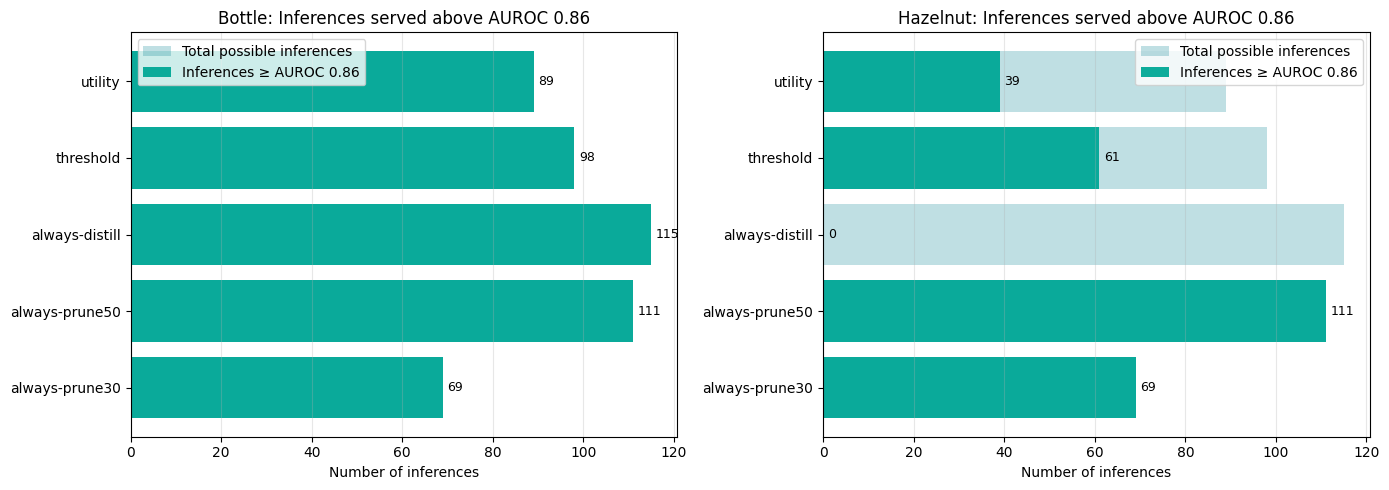

In [40]:
import matplotlib.pyplot as plt

ACC_FLOOR = 86

# --------------------------
# Data
# --------------------------
served = {
    "bottle": {
        "always-prune30": 69,
        "always-prune50": 111,
        "always-distill": 115,
        "threshold": 98,
        "utility": 89,
    },
    "hazelnut": {
        "always-prune30": 69,
        "always-prune50": 111,
        "always-distill": 0,
        "threshold": 61,
        "utility": 39,
    },
}

total = {
    "always-prune30": 69,
    "always-prune50": 111,
    "always-distill": 115,
    "threshold": 98,
    "utility": 89,
}

# Colors
served_color = "#00a896"
total_color = "#028090"

# --------------------------
# Plot
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, cat in zip(axes, ["bottle", "hazelnut"]):

    labels = list(served[cat].keys())
    y_pos = range(len(labels))

    served_vals = [served[cat][k] for k in labels]
    total_vals = [total[k] for k in labels]

    # Background bars (total possible)
    ax.barh(
        y_pos,
        total_vals,
        color=total_color,
        alpha=0.25,
        label="Total possible inferences"
    )

    # Foreground bars (served above AUROC threshold)
    bars = ax.barh(
        y_pos,
        served_vals,
        color=served_color,
        alpha=0.95,
        label="Inferences ≥ AUROC 0.86"
    )

    # Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Number of inferences")
    ax.set_title(f"{cat.capitalize()}: Inferences served above AUROC 0.86")

    ax.grid(axis="x", alpha=0.3)

    # Value annotations
    for bar, v in zip(bars, served_vals):
        ax.text(
            v + 1,
            bar.get_y() + bar.get_height() / 2,
            str(v),
            va="center",
            fontsize=9
        )

    ax.legend()

plt.tight_layout()
plt.savefig("InferencesServedAboveFloor.png", dpi=300, bbox_inches="tight")
plt.show()

Diagram

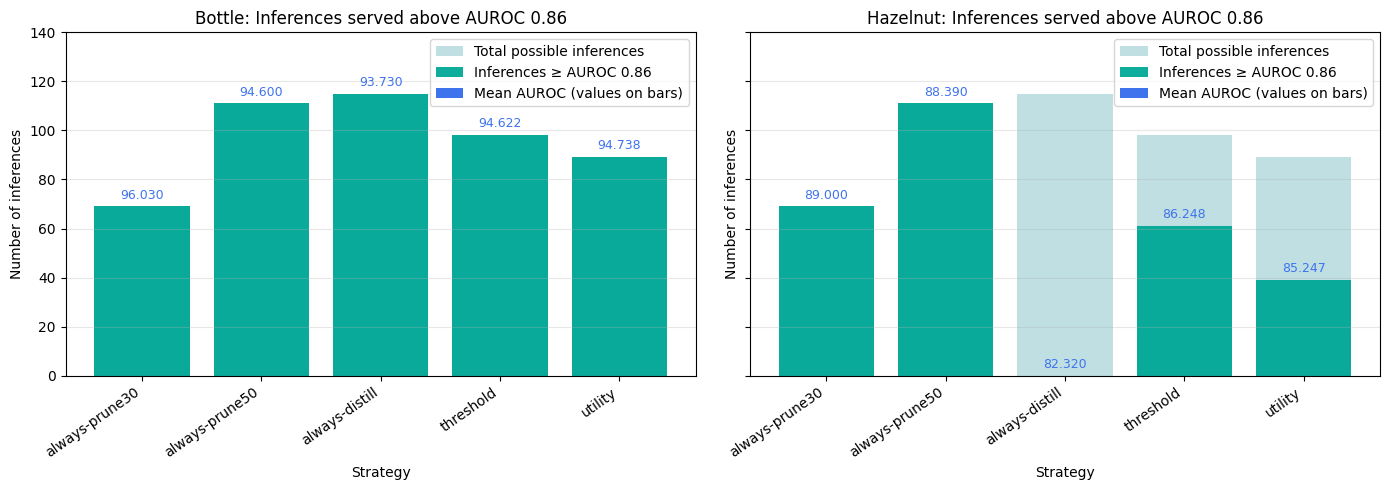

In [41]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

ACC_FLOOR = 86


# --------------------------
# Data
# --------------------------

strategies = [
    "always-prune30",
    "always-prune50",
    "always-distill",
    "threshold",
    "utility"
]

# Served inferences above AUROC floor
served = {
    "bottle": [69, 111, 115, 98, 89],
    "hazelnut": [69, 111, 0, 61, 39],
}

# Total possible inferences
total = {
    "bottle": [69, 111, 115, 98, 89],
    "hazelnut": [69, 111, 115, 98, 89],
}

# Mean AUROC annotations
mean_auroc = {
    "bottle": [96.030, 94.600, 93.730, 94.622, 94.738],
    "hazelnut": [89.000, 88.390, 82.320, 86.248, 85.247],
}

# Colors
served_color = "#00a896"
total_color = "#028090"
mean_auroc_color = "#3f73ed"

# --------------------------
# Plot
# --------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, category in zip(axes, ["bottle", "hazelnut"]):

    values = served[category]
    totals = total[category]
    aurocs = mean_auroc[category]

    x = np.arange(len(strategies))

    # Background bars: total possible inferences
    ax.bar(
        x,
        totals,
        color=total_color,
        alpha=0.25,
        label="Total possible inferences"
    )

    # Foreground bars: served above floor
    bars = ax.bar(
        x,
        values,
        color=served_color,
        alpha=0.95,
        label=f"Inferences ≥ AUROC {ACC_FLOOR/100:.2f}"
    )

    # X-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        strategies,
        rotation=35,
        ha="right"
    )

    ax.set_xlabel("Strategy")
    ax.set_ylabel("Number of inferences")

    ax.set_title(
        f"{category.capitalize()}: Inferences served above AUROC {ACC_FLOOR/100:.2f}"
    )

    ax.set_ylim(0, 140)
    ax.grid(axis="y", alpha=0.3)

        # Add mean AUROC annotations
    for bar, auroc in zip(bars, aurocs):

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2,
            f"{auroc:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=mean_auroc_color
        )

    # Custom legend handles
    handles, labels = ax.get_legend_handles_labels()

    handles.append(
        Patch(
            facecolor=mean_auroc_color,
            label="Mean AUROC (values on bars)"
        )
    )

    ax.legend(handles=handles, loc="upper right")


plt.tight_layout()

plt.savefig(
    "InferencesAboveFloor_WithMeanAUROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Sensitivity

How does the outcome change when battery size varies?

--> Repeat simulation and apply different strategies on different battery capacities

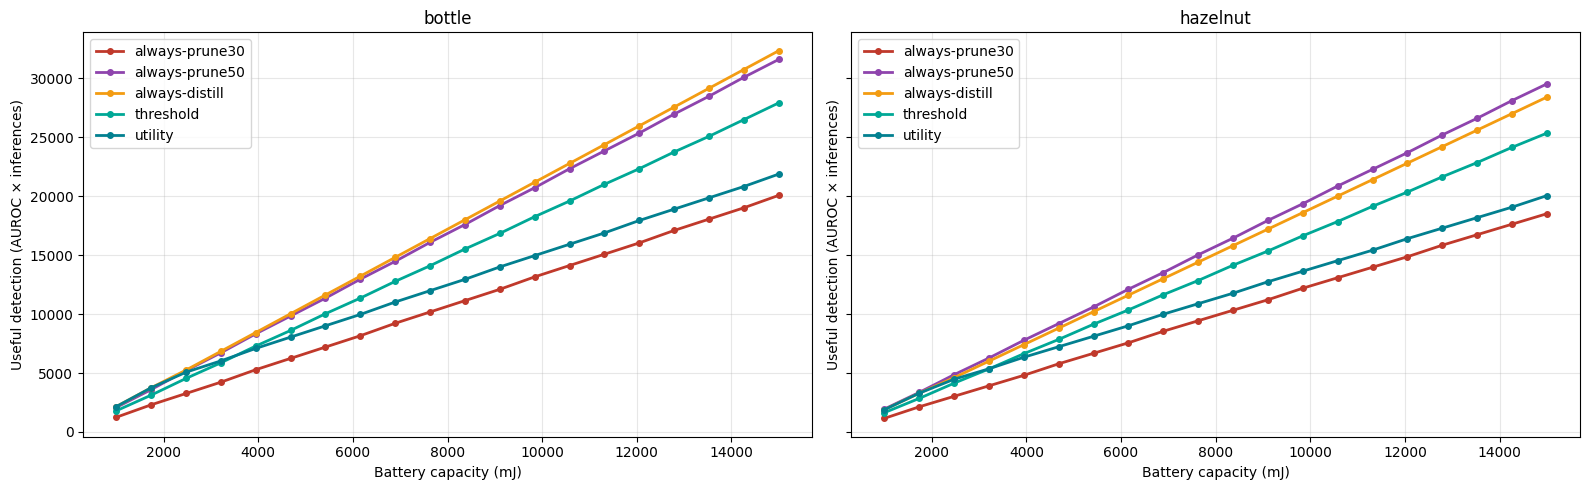

In [42]:
caps = np.linspace(1000, 15000, 20)

strategies = {
    'always-prune30': 'prune30',
    'always-prune50': 'prune50',
    'always-distill': 'distill',
    'threshold': 'threshold',
    'utility': 'utility',
}

# --------------------------
# Unified color system
# --------------------------
colors = {
    "threshold": "#00a896",
    "utility": "#028090",

    # high-contrast, distinct, colorblind-safe-ish choices
    "always-prune30": "#c0392b",
    "always-prune50": "#8e44ad",
    "always-distill": "#f39c12",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for col, cat in enumerate(['bottle', 'hazelnut']):

    ax = axes[col]

    for strat in strategies:

        util = []

        for cap in caps:
            tr = simulate(cat, strategies[strat], cap_mJ=cap)

            util.append(
                np.mean(tr['auroc']) * len(tr['auroc'])
                if len(tr['auroc']) > 0 else 0
            )

        ax.plot(
            caps,
            util,
            label=strat,
            color=colors[strat],
            lw=2,
            marker='o',
            ms=4
        )

    ax.set_title(f'{cat}')
    ax.set_xlabel('Battery capacity (mJ)')
    ax.grid(alpha=0.3)
    ax.set_ylabel('Useful detection (AUROC × inferences)')

axes[0].legend(loc='best')
axes[1].legend(loc='best')

plt.tight_layout()
plt.savefig("Sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Adaptive Model Selection under Intermittent Energy Harvesting

In this scenario, the MCU is powered by an intermittent energy source (e.g., solar or RF harvesting) charging a small supercapacitor. Because harvested energy arrives in bursts and the buffer capacity is limited, the device must dynamically select the most appropriate model according to the energy currently available.

| Supercapacitor charge | Deployment | Chosen Model |
|---|---|---|
| >69.7 mJ | accurate | Prune30 |
| >42.8 mJ | mid | Prune 50 |
| >41.4 mJ | cheap | Distill |
| <41.4. MJ | Miss | - |

The simulation...
 - generates a bursty energy-harvesting trace (`make_harvest_trace(...)`), representing changing environmental conditions such as sunlight variations or temporary shading.
  - limits capacity and each cycle, adds the harvested energy to the supercapacitor
  - excess energy is discarded once the buffer is full.

Device behavior...
 - Dynamically select the most accurate model that can be executed with the current energy available in the buffer

‼️Fixed strategies might miss inference opportunities when not enough energy is available.

For each strategy, we report the number of successful inferences, missed cycles, mean AUROC, and the number of inferences performed while maintaining performance above the required accuracy floor (0.86).


In [43]:
import numpy as np

# ============ ENERGY HARVESTING SCENARIO ============
# A supercapacitor buffer charged by an intermittent source (e.g. solar/RF).
# Energy arrives in bursts; the buffer has finite capacity (surplus is lost when full).
# The device must choose a model each cycle based on CURRENT buffer level.

CAP_mJ = 400.0        # supercapacitor capacity (small — bursty regime)
N_CYCLES = 1000       # simulation length
FLOOR = 86

HARVEST_MEANS = [15.0, 25.0, 35.0]


def make_harvest_trace(n, mean, kind='bursty'):
    if kind == 'bursty':
        trace = []
        while len(trace) < n:
            on = np.random.rand() < 0.5
            length = np.random.randint(20, 60)
            level = mean * 2.2 if on else mean * 0.15
            trace += [
                max(0, np.random.normal(level, level * 0.3))
                for _ in range(length)
            ]
        return np.array(trace[:n])

    return np.random.normal(mean, mean * 0.5, n).clip(0)


def simulate_harvest(cat, strategy, harvest, ladder=None, floor=None):
    """Each cycle: harvest energy into the cap, then try to run a model."""

    L = ladder if ladder else LADDER[cat]
    ladder_sorted = sorted(
        L.items(),
        key=lambda kv: -kv[1]["energy_mJ"]
    )

    buf = CAP_mJ * 0.5
    served = []
    missed = 0

    for t in range(len(harvest)):
        buf = min(CAP_mJ, buf + harvest[t])

        if strategy == "adaptive":
            chosen = None
            for name, m in ladder_sorted:
                if buf >= m["energy_mJ"] + IDLE_mJ:
                    chosen = (name, m)
                    break

            if chosen is None:
                missed += 1
                continue

        else:
            name = strategy
            m = L[name]

            if buf < m["energy_mJ"] + IDLE_mJ:
                missed += 1
                continue

            chosen = (name, m)

        name, m = chosen
        buf -= m["energy_mJ"] + IDLE_mJ
        served.append(m["auroc"])

    return {
        "served": served,
        "missed": missed,
        "n_served": len(served),
        "mean_auroc": np.mean(served) if served else 0,
        "above_floor": sum(a >= floor for a in served) if floor is not None else len(served),
    }


In [44]:
for HARVEST_MEAN in HARVEST_MEANS:

    np.random.seed(0)  # Same harvest realization for fair comparison
    harvest = make_harvest_trace(N_CYCLES, HARVEST_MEAN)

    print(f"\n{'='*60}")
    print(f"Mean harvested energy = {HARVEST_MEAN:.0f} mJ")
    print(f"{'='*60}")

    for CAT in ["bottle", "hazelnut"]:

        print(f"\n{CAT.upper()}")

        for strat in ["prune30", "prune50", "distill", "adaptive"]:

            r = simulate_harvest(
                CAT,
                strat,
                harvest,
                floor=FLOOR,
            )

            print(
                f"  {strat:10s}: "
                f"served {r['n_served']:4d}, "
                f"missed {r['missed']:4d}, "
                f"mean AUROC {r['mean_auroc']:.3f}, "
                f"above-floor {r['above_floor']:4d}"
            )


Mean harvested energy = 15 mJ

BOTTLE
  prune30   : served  232, missed  768, mean AUROC 96.030, above-floor  232
  prune50   : served  372, missed  628, mean AUROC 94.600, above-floor  372
  distill   : served  384, missed  616, mean AUROC 93.730, above-floor  384
  adaptive  : served  339, missed  661, mean AUROC 94.755, above-floor  339

HAZELNUT
  prune30   : served  232, missed  768, mean AUROC 89.000, above-floor  232
  prune50   : served  372, missed  628, mean AUROC 88.390, above-floor  372
  distill   : served  384, missed  616, mean AUROC 82.320, above-floor    0
  adaptive  : served  335, missed  665, mean AUROC 88.035, above-floor  309

Mean harvested energy = 25 mJ

BOTTLE
  prune30   : served  386, missed  614, mean AUROC 96.030, above-floor  386
  prune50   : served  571, missed  429, mean AUROC 94.600, above-floor  571
  distill   : served  576, missed  424, mean AUROC 93.730, above-floor  576
  adaptive  : served  476, missed  524, mean AUROC 95.272, above-floor  476


### Diagram

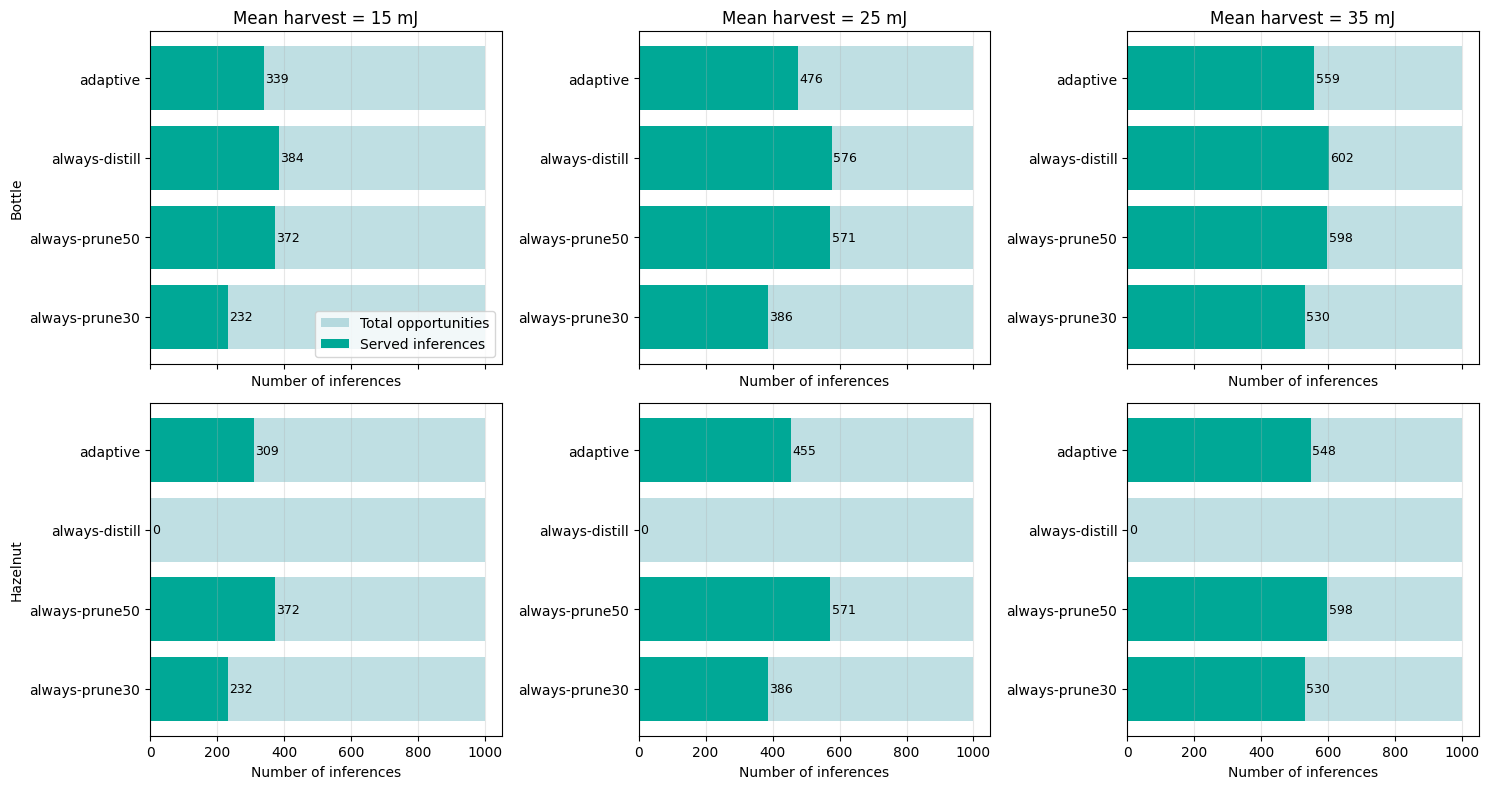

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

CAP_mJ = 400.0
N_CYCLES = 1000
FLOOR = 86

HARVEST_MEANS = [15.0, 25.0, 35.0]

served_color = "#00a896"
total_color = "#028090"

strategies = [
    ("prune30", "always-prune30"),
    ("prune50", "always-prune50"),
    ("distill", "always-distill"),
    ("adaptive", "adaptive"),
]

fig, axes = plt.subplots(
    2,
    len(HARVEST_MEANS),
    figsize=(5 * len(HARVEST_MEANS), 8),
    sharex=True
)

for col, mean in enumerate(HARVEST_MEANS):

    # Same random realization for every strategy at this harvest level
    np.random.seed(0)
    harvest = make_harvest_trace(N_CYCLES, mean)

    for row, cat in enumerate(["bottle", "hazelnut"]):

        ax = axes[row, col]

        labels = []
        foreground_vals = []
        total_vals = []

        for strategy, label in strategies:

            r = simulate_harvest(
                cat,
                strategy,
                harvest,
                floor=FLOOR,
            )

            labels.append(label)
            foreground_vals.append(r["above_floor"])          # Served above AUROC floor
            total_vals.append(r["n_served"] + r["missed"])    # Total inference opportunities

        y = np.arange(len(labels))

        # Background bars (total opportunities)
        ax.barh(
            y,
            total_vals,
            color=total_color,
            alpha=0.25,
            label="Total opportunities" if (row == 0 and col == 0) else None,
        )

        # Foreground bars (served)
        bars = ax.barh(
            y,
            foreground_vals,
            color=served_color,
            label="Served inferences" if (row == 0 and col == 0) else None,
        )

        # Value labels
        for bar, value in zip(bars, foreground_vals):
            ax.text(
                value + 5,
                bar.get_y() + bar.get_height() / 2,
                str(value),
                va="center",
                fontsize=9,
            )

        ax.set_yticks(y)
        ax.set_yticklabels(labels)
        ax.grid(axis="x", alpha=0.3)

        if row == 0:
            ax.set_title(f"Mean harvest = {mean:.0f} mJ")

        if col == 0:
            ax.set_ylabel(cat.capitalize())

        ax.set_xlabel("Number of inferences")

axes[0, 0].legend(loc="lower right")

plt.tight_layout()
plt.savefig(
    "HarvestSweep_InferencesServed.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Daigram

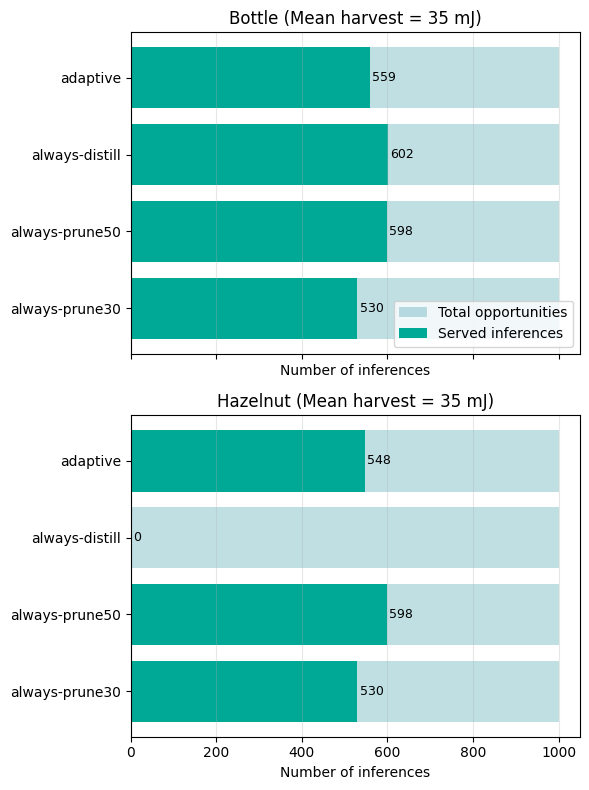

In [46]:
import matplotlib.pyplot as plt
import numpy as np

CAP_mJ = 400.0
N_CYCLES = 1000
FLOOR = 86

HARVEST_MEAN = 35.0  # single harvest condition

served_color = "#00a896"
total_color = "#028090"

strategies = [
    ("prune30", "always-prune30"),
    ("prune50", "always-prune50"),
    ("distill", "always-distill"),
    ("adaptive", "adaptive"),
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(6, 8),
    sharex=True
)

# Same random realization for every strategy
np.random.seed(0)
harvest = make_harvest_trace(N_CYCLES, HARVEST_MEAN)

for row, cat in enumerate(["bottle", "hazelnut"]):

    ax = axes[row]

    labels = []
    foreground_vals = []
    total_vals = []

    for strategy, label in strategies:

        r = simulate_harvest(
            cat,
            strategy,
            harvest,
            floor=FLOOR,
        )

        labels.append(label)
        foreground_vals.append(r["above_floor"])          # Served above AUROC floor
        total_vals.append(r["n_served"] + r["missed"])    # Total inference opportunities

    y = np.arange(len(labels))

    # Background bars (total opportunities)
    ax.barh(
        y,
        total_vals,
        color=total_color,
        alpha=0.25,
        label="Total opportunities" if row == 0 else None,
    )

    # Foreground bars (served)
    bars = ax.barh(
        y,
        foreground_vals,
        color=served_color,
        label="Served inferences" if row == 0 else None,
    )

    # Value labels
    for bar, value in zip(bars, foreground_vals):
        ax.text(
            value + 5,
            bar.get_y() + bar.get_height() / 2,
            str(value),
            va="center",
            fontsize=9,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.grid(axis="x", alpha=0.3)

    ax.set_title(f"{cat.capitalize()} (Mean harvest = {HARVEST_MEAN:.0f} mJ)")
    ax.set_xlabel("Number of inferences")

axes[0].legend(loc="lower right")

plt.tight_layout()
plt.savefig(
    "Harvest_InferencesServed.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### This figure illustrates the behavior of the adaptive policy during the first 300 harvesting cycles.

Energy buffer over time

Selected model over time

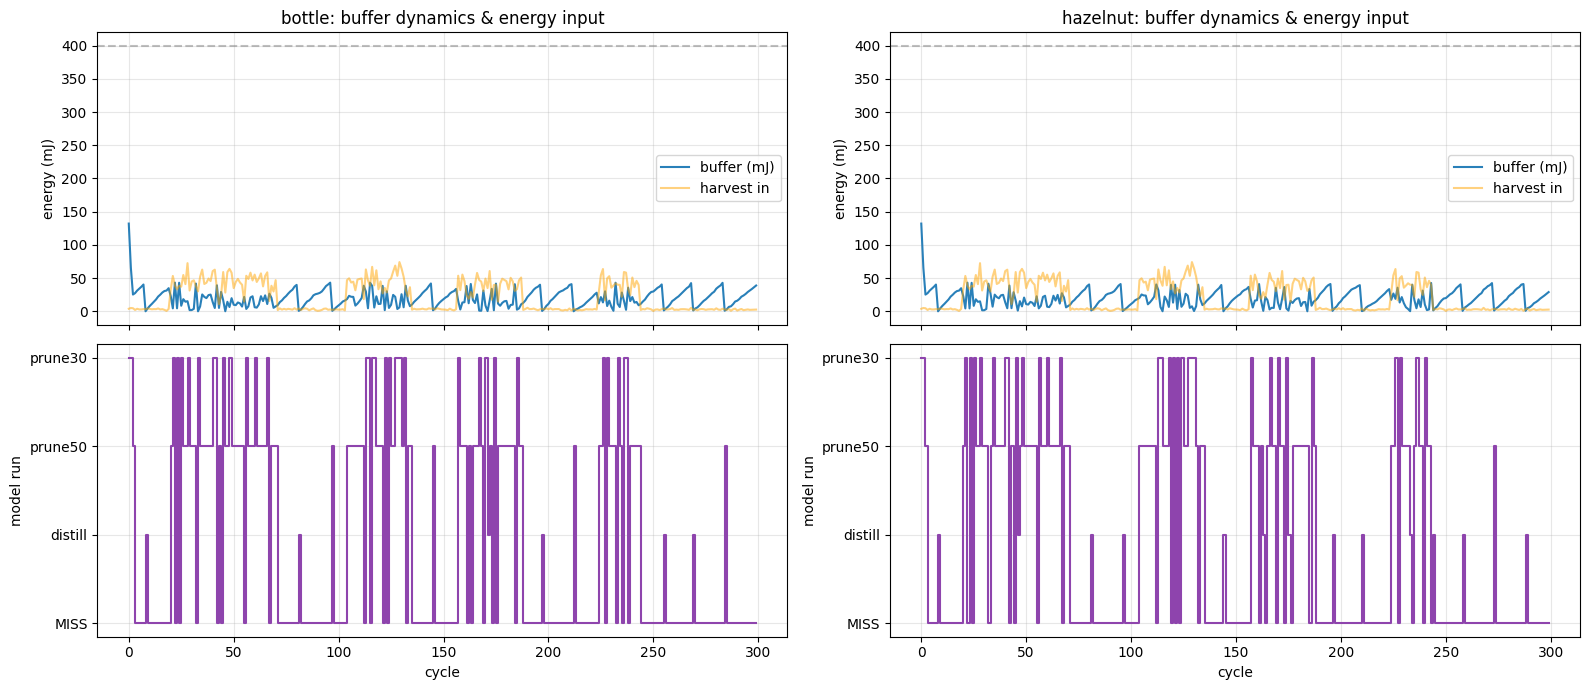

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 7), sharex=True)

model_map = {'prune30': 3, 'prune50': 2, 'distill': 1}

for col, CAT in enumerate(['bottle', 'hazelnut']):

    buf_trace, model_trace = [], []

    buf = CAP_mJ * 0.5
    L = LADDER[CAT]
    ladder_sorted = sorted(L.items(), key=lambda kv: -kv[1]['energy_mJ'])

    h = harvest[CAT] if isinstance(harvest, dict) else harvest

    for t in range(300):

        buf = min(CAP_mJ, buf + h[t])

        chosen = None
        for name, m in ladder_sorted:
            if buf >= m['energy_mJ'] + IDLE_mJ:
                chosen = (name, m)
                break

        if chosen:
            buf -= chosen[1]['energy_mJ'] + IDLE_mJ
            model_trace.append(model_map[chosen[0]])
        else:
            model_trace.append(0)

        buf_trace.append(buf)

    # -----------------------
    # TOP: buffer + harvest
    # -----------------------
    ax1 = axes[0, col]
    ax1.plot(buf_trace, color='#2980b9', label='buffer (mJ)')
    ax1.plot(h[:300], color='orange', alpha=0.5, label='harvest in')
    ax1.axhline(CAP_mJ, ls='--', color='gray', alpha=.5)

    ax1.set_title(f'{CAT}: buffer dynamics & energy input')
    ax1.set_ylabel('energy (mJ)')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # -----------------------
    # BOTTOM: model trace
    # -----------------------
    ax2 = axes[1, col]
    ax2.plot(model_trace, drawstyle='steps-post', color='#8e44ad')
    ax2.set_yticks([0,1,2,3])
    ax2.set_yticklabels(['MISS','distill','prune50','prune30'])
    ax2.set_xlabel('cycle')
    ax2.set_ylabel('model run')
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ModelSelection_BufferDynamics_SmallerMeanHarvest.png", dpi=300, bbox_inches="tight")
plt.show()

 - The upper plot shows the evolution of the supercapacitor energy buffer as intermittent energy is harvested.

 - The lower plot shows the model selected by the adaptive policy at each cycle.

 This visualization demonstrates how the adaptive strategy dynamically balances detection performance and energy availability under intermittent power conditions.

### Save images to Drive

In [47]:
import shutil
import glob
import os
from google.colab import drive

drive.mount('/content/drive')

dst = "/content/drive/MyDrive/mvtec_stage4"
os.makedirs(dst, exist_ok=True)  # 👈 creates folder if it doesn't exist

for img in glob.glob("/content/*.png"):
    shutil.copy(img, dst)

print("Saved PNG images to Drive ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved PNG images to Drive ✓


# Stage 4 — Report & Project Conclusion

## Does runtime adaption between compressed models provide a practical advantage under energy constraints?

The **goal** was to...

 - not miss inference opportunities by choosing a less expensive model when energy is low (trading for accuracy)

**--> The experiments show that the adaptive policies do **not** outperform the best fixed strategy**

Across the simulated battery scenarios, the static `prune50 L1` model consistently provides the strongest trade-off between accuracy and energy consumption.
This model achieves **long operating lifetime** while **maintaining performance** above the required accuracy floor.

## Conclusion

‼️The original goal of sustaining long operating lifetime while mainaining performance is **not met by adaptively switching compressed models during runtime**.

Instead, for the given Hardware setup, a carefully designed compressed model is robust enough, such that runtime adaption only gives little benefit...

| static runtime | > | adaptive runtime |
|---|---|---|

--> Model compression itself can already solve a big amount of the energy-efficiency problem.

## Llimitations/ Discussion

* **Energy is estimated** from datasheet active current (6.3 mA @ 3.3 V), not measured with a current probe.
    * The policy depends on relative energy costs between models
    * energy ~ measured latency
* **Battery and harvesting models are idealized** - following effects not taken into account:
    * linear energy accounting
    * no voltage sag
    * leakage
    * temperature effects
    * conversion losses
* **The adaptive policy is simulated off-device.**
* **`distill` is nearly dominated** by `prune50 L1` (similar energy cost but consistently lower accuracy)
    * the effective model ladder is largely reduced to `prune30 L1` and `prune50 L1`.

## The full project arc

1. **Stage 1** — compact autoencoder anomaly detector on MVTec (bottle = 0.9667 AUROC, hazelnut = 0.8854 AUROC at 64×64), with a fixed scoring protocol.
2. **Stage 2** — systematic compression (quantization, L1/Taylor pruning, distillation) and Pareto characterization.
3. **Stage 3** — real INT8 TFLite deployment on the Arduino: measured latency, memory, energy, and on-device AUROC matching software within 0.01.
4. **Stage 4** — evaluation of energy-aware adaptive inference strategies under battery and harvesting constraints.

### The overall conclusion is

that compression makes deployment on resource-constrained hardware possible, while adaptive inference is not universally beneficial.

In this case, the compressed `prune50 L1` model already represents a highly effective operating point, demonstrating that the simplest strategy can be the most practical for embedded anomaly detection.
